## 
    Time period	: 1940 - 2023
    
    location:   s(glost,k=5)  
    
    scale	    s(glost,k=2)
    shape       1



In [4]:
itest='loc_sck2_loess'

In [5]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import scipy
import cftime
import cartopy
import cartopy.crs as ccrs
import matplotlib.colors as colors
import cmaps
from xhistogram.xarray import histogram
from statsmodels.nonparametric.smoothers_lowess import lowess as  sm_lowess
from copy import copy

In [6]:
import rpy2
from rpy2.robjects.packages import importr, data
from rpy2.robjects import pandas2ri
import rpy2.robjects as ro
from rpy2.robjects import globalenv

extRemes = importr("extRemes")
evgam = importr("evgam")
%load_ext rpy2.ipython

In [7]:
%config InlineBackend.figure_format = 'retina'
plt.style.use("cma.mplstyle")

In [8]:
state_borders =\
cartopy.feature.NaturalEarthFeature(category='cultural',\
        name='admin_1_states_provinces_lakes', scale='50m', facecolor='none')

# READ AFI, DJF Temperature and topography FILES

In [9]:
yearb=1941
yeare=2023

files=[f'../AFI/AFIT/AFI_ERA5_{iyear}.nc' for iyear in range(yearb,yeare+1)]

ds=xr.open_mfdataset(files)
ds=ds.sortby('lat')
ds['AFI']=ds['AFI']*5/9.
ds['time']=np.arange(yearb,yeare+1,1)

return_periods=[2, 5, 10, 25, 50, 100]
Tlon=ds.lon.data
Tlat=ds.lat.data

units='degree-days (°C)'

# Read GLOST

In [10]:
fileGLOST = '../AFI/NOAA_GLOST_anomaly.csv'
df_glost=pd.read_csv(fileGLOST,skiprows=4)
df_glost['Year']=pd.to_datetime(df_glost['Year'], format='%Y%m')
df_glost=df_glost.rename(columns={'Year': 'time'})

In [11]:
ds_glost=df_glost.set_index(['time']).to_xarray()

In [12]:
sm_x, smooth_glost = sm_lowess(ds_glost['Anomaly'], ds_glost['time'],  frac=(30*12)/len(ds_glost['time']), 
                           it=5, return_sorted = True).T
smooth_glost=xr.DataArray(smooth_glost,dims=['time'],coords={'time':ds_glost['time']})           

In [13]:
def ann_mean(var):
    month_length = var.time.dt.days_in_month
    wgts = month_length.groupby("time.year") / month_length.groupby("time.year").sum()
    var_ann = (var*wgts).groupby("time.year").sum()
    return var_ann

In [14]:
ann_glost=ann_mean(smooth_glost)
ann_glost=ann_glost.rename({'year':'time'})

In [15]:
xxx=[np.datetime64(str(ann_glost['time'].data[it])) for it in range(0,len(ann_glost['time']))]


Text(0.5, 1.0, 'GLOST timeseries')

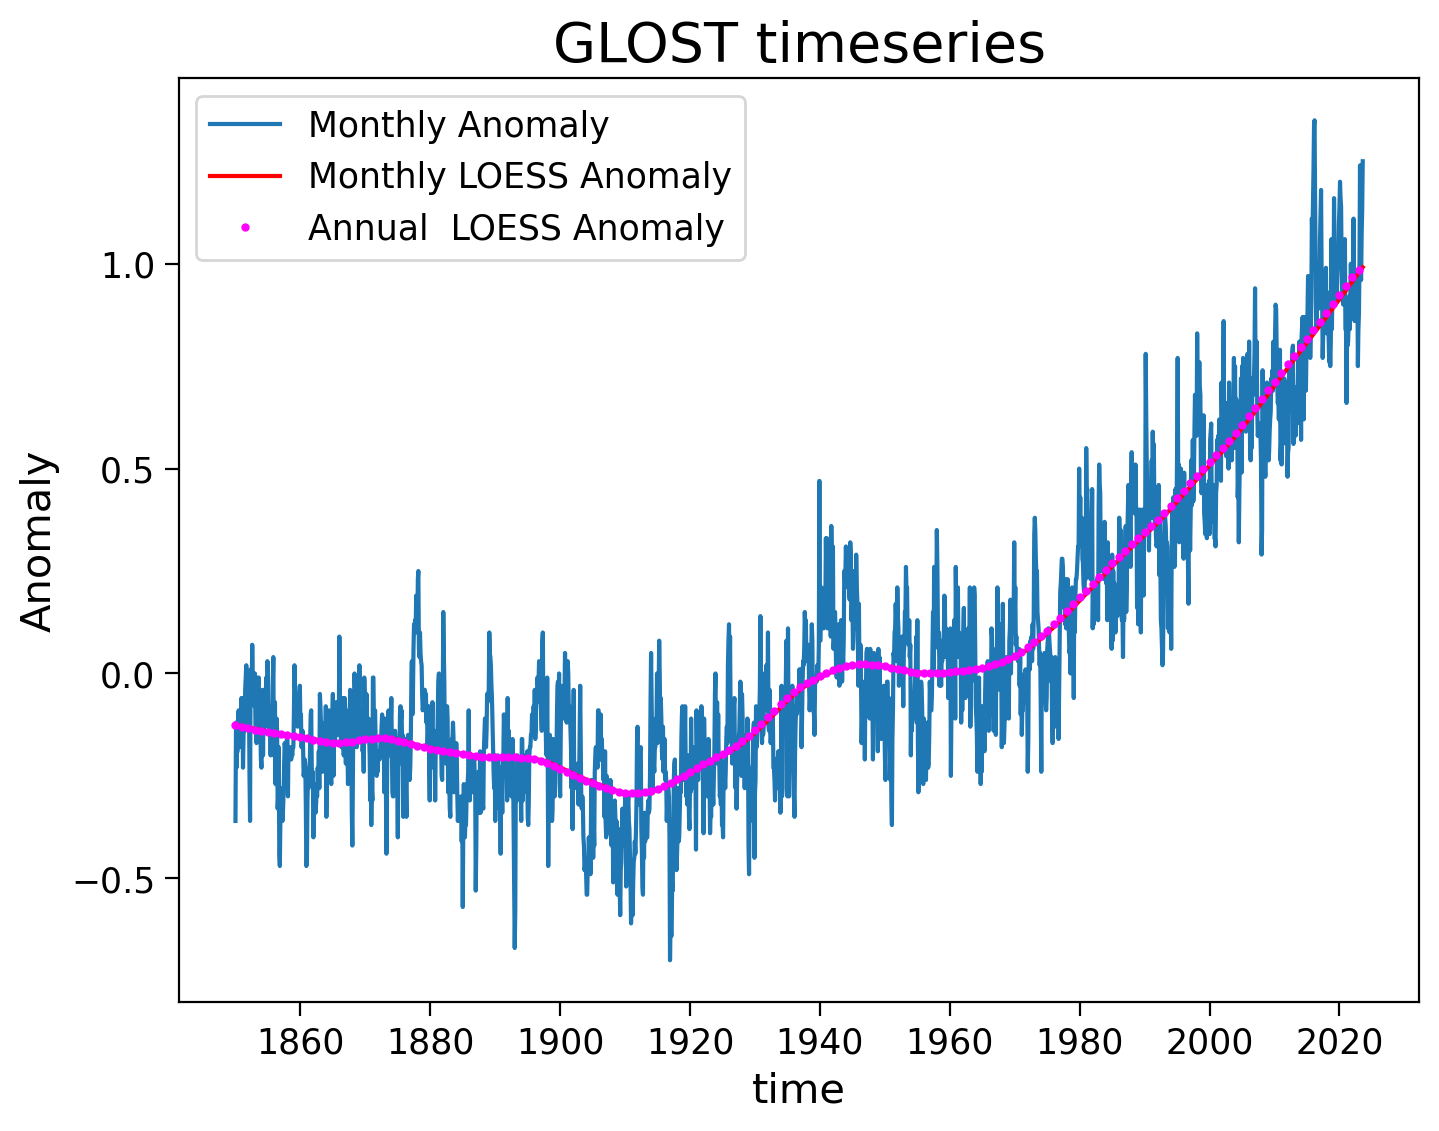

In [16]:
ds_glost['Anomaly'].plot(label='Monthly Anomaly')
plt.plot(ds_glost['time'], smooth_glost, color='red',label='Monthly LOESS Anomaly')
plt.plot(xxx, ann_glost,marker='o', linestyle='', color='magenta',markersize=2,label='Annual  LOESS Anomaly')
plt.legend()
plt.title('GLOST timeseries',fontsize=20)


In [17]:
ann_glost=ann_glost.sel(time=ds['time'])
ann_glost=ann_glost.rename({'Anomaly'})

# Merge AFI with GLOST

In [18]:
ds=ds.merge({'glost':ann_glost})

# Reduce domain for testing purpose

In [19]:
lon_min=235;lon_max=293
lat_min=28;lat_max=50

In [20]:
ds=ds.sel(lon=slice(lon_min,lon_max),lat=slice(lat_min,lat_max))
Tlon=ds.lon.data
Tlat=ds.lat.data

# Define EVGAM parameters for smoothness 

In [21]:
# parameters for smoothness 
%R fmla_gev <- list(AFI ~ s(glost,k=5) , ~ s(glost,k=2) , ~ 1)

# evgam fit_gev and rl100

In [22]:
spval=-99999
Rlocation=xr.zeros_like(ds['AFI'].load())*np.nan
Rshape=xr.zeros_like(ds['AFI'].load())*np.nan
Rscale=xr.zeros_like(ds['AFI'].load())*np.nan
Rrl100=xr.zeros_like(ds['AFI'].load())*np.nan
NSlocpvalue=xr.zeros_like(ds['AFI'].load().mean('time'))*np.nan
NSscapvalue=xr.zeros_like(ds['AFI'].load().mean('time'))*np.nan

mask=xr.where(np.isnan(ds['AFI'].mean('time'))==False,1,0)

idlat,idlon=np.where(mask==1)
for ij in range(0,len(idlat)):
  jj=idlat[ij]
  ii=idlon[ij]
  ilon=Tlon[ii]
  ilat=Tlat[jj]
  # Extract values for boxes
  dsij=ds.sel(lon=ilon,lat=ilat).load()
  df = dsij.to_dataframe()
  df = df.reset_index()
  # Remove zeros and NAN 
  # Remove timeseries with less than 15 data (as in Bilotta et al.)
  # Save rows removed
  dfsave=df[(df['AFI'] <= 0.)|(df['AFI'].isna())]
  df = df[df['AFI'] > 0.]

  dfsave=pd.concat([dfsave, df.groupby(['lon', 'lat']).filter(lambda x: len(x) <= 49)])
  df=df.groupby(['lon', 'lat']).filter(lambda x: len(x) > 49)
  if df.empty == True:
    Rlocation.loc[{'lat':ilat,'lon':ilon}] = spval
    Rscale.loc[{'lat':ilat,'lon':ilon}] = spval
    Rshape.loc[{'lat':ilat,'lon':ilon}] = spval
    Rrl100.loc[{'lat':ilat,'lon':ilon}] = spval
    NSlocpvalue.loc[{'lat':ilat,'lon':ilon}] = spval
    NSscapvalue.loc[{'lat':ilat,'lon':ilon}] = spval
  else:  
    # Convert xarray to pandas DataFrame to R data.frame
    # You can now work with 'r_df' in R
    with (ro.default_converter + pandas2ri.converter).context():
      r_df = ro.conversion.get_conversion().py2rpy(df)
    globalenv['r_df'] = r_df

    # EVGAM model fitting  
    %R m_gev <- evgam(fmla_gev, r_df, family = "gev")
    %R pp <- summary(m_gev)
    %R location_pvalue <- pp[[2]][['location']][['Pr(>|t|)']]
    %R scale_pvalue <- pp[[2]][['logscale']][['Pr(>|t|)']]
    %R gev_pred <- predict(m_gev, r_df, type = "response")
    %R gev_rl100 <- predict(m_gev, r_df, prob = 0.99)
    %R -o gev_pred,gev_rl100,location_pvalue,scale_pvalue # get R data to python

    # Convert R data.frame to xarray
    gev_pred['time']=df['time'].values
    dsgev_pred=gev_pred.set_index(['time']).to_xarray()

    ######
    ######
    gev_rl100['time']=df['time'].values
    dsgev_rl100=gev_rl100.set_index(['time']).to_xarray()
    
    ######
    ######

    Rlocation.loc[{'time':df['time'].values,'lat':ilat,'lon':ilon}] = dsgev_pred['location'][:]
    Rscale.loc[{'time':df['time'].values,'lat':ilat,'lon':ilon}] = dsgev_pred['scale'][:]
    Rshape.loc[{'time':df['time'].values,'lat':ilat,'lon':ilon}] = dsgev_pred['shape'][:]
    Rrl100.loc[{'time':df['time'].values,'lat':ilat,'lon':ilon}] = dsgev_rl100['q:0.99'][:]
    NSlocpvalue.loc[{'lat':ilat,'lon':ilon}] = location_pvalue[0]
    NSscapvalue.loc[{'lat':ilat,'lon':ilon}] = scale_pvalue[0]


In addition: Warning message:
In smooth.construct.tp.smooth.spec(object, dk$data, dk$knots) :
  basis dimension, k, increased to minimum possible



In addition: Warning message:
In smooth.construct.tp.smooth.spec(object, dk$data, dk$knots) :
  basis dimension, k, increased to minimum possible



In addition: Warning message:
In smooth.construct.tp.smooth.spec(object, dk$data, dk$knots) :
  basis dimension, k, increased to minimum possible



In addition: Warning message:
In smooth.construct.tp.smooth.spec(object, dk$data, dk$knots) :
  basis dimension, k, increased to minimum possible



In addition: Warning message:
In smooth.construct.tp.smooth.spec(object, dk$data, dk$knots) :
  basis dimension, k, increased to minimum possible



...

In addition: Warning message:
In smooth.construct.tp.smooth.spec(object, dk$data, dk$knots) :
  basis dimension, k, increased to minimum possible



In addition: Warning message:
In smooth.construct.tp.smooth.spec(object, dk$data, dk$knots) :
  basis dimension, k, increased to minimum possible



In addition: Warning message:
In smooth.construct.tp.smooth.spec(object, dk$data, dk$knots) :
  basis dimension, k, increased to minimum possible



In addition: Warning message:
In smooth.construct.tp.smooth.spec(object, dk$data, dk$knots) :
  basis dimension, k, increased to minimum possible



In addition: Warning message:
In smooth.construct.tp.smooth.spec(object, dk$data, dk$knots) :
  basis dimension, k, increased to minimum possible



In [24]:
itest

'loc_sck2_loess'

In [25]:
dsout=Rrl100.to_dataset(name='rl100')
dsout=dsout.merge({'location':Rlocation,'scale':Rscale,'shape':Rshape,\
    'NSlocpvalue':NSlocpvalue,'NSscapvalue':NSscapvalue,'glost':ds['glost']})
dsout.to_netcdf(f'../AFI/CONUS_afi_return.evgam.{yearb}_{yeare}_{itest}.nc')